# Augmented Dataset Visualization & Analysis

Compare original dataset with new augmented dataset.

**Includes:**
- Image count comparison
- Object size distribution (COCO-based: small, medium, large)
- Augmented image preview with new objects highlighted
- Comprehensive statistics and visualizations


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# ============ CONFIGURATION ============
PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")

# Path to datasets
# ORIGINAL_DATASET_TRAIN = PROJECT_ROOT / "datasets" / "minneapple" / "yolo_format" / "minneapple_yolo" / "train"
# AUGMENTED_DATASET_TRAIN = PROJECT_ROOT / ".cache_result" / "augmented_dataset" / "random_copy_paste" / "train"
ORIGINAL_DATASET_TRAIN = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train")
AUGMENTED_DATASET_TRAIN = Path("/home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_4_Copy_Paste_Augmentation/augmented_dataset/train")

print("="*70)
print("DATASET PATHS")
print("="*70)
print(f"Original train:     {ORIGINAL_DATASET_TRAIN}")
print(f"  Images exist:     {(ORIGINAL_DATASET_TRAIN / 'images').exists()}")
print(f"  Labels exist:     {(ORIGINAL_DATASET_TRAIN / 'labels').exists()}")
print(f"\nAugmented train:    {AUGMENTED_DATASET_TRAIN}")
print(f"  Images exist:     {(AUGMENTED_DATASET_TRAIN / 'images').exists()}")
print(f"  Labels exist:     {(AUGMENTED_DATASET_TRAIN / 'labels').exists()}")


DATASET PATHS
Original train:     /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train
  Images exist:     True
  Labels exist:     True

Augmented train:    /home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_4_Copy_Paste_Augmentation/augmented_dataset/train
  Images exist:     True
  Labels exist:     True


In [2]:
# Count images in datasets
def count_images(images_dir):
    """Count original and augmented images"""
    images_dir = Path(images_dir)
    image_files = list(images_dir.glob("*.png")) + list(images_dir.glob("*.jpg"))
    augmented = [f for f in image_files if f.stem.startswith("aug_")]
    original = [f for f in image_files if not f.stem.startswith("aug_")]
    
    return {
        "total": len(image_files),
        "original": len(original),
        "augmented": len(augmented),
        "files": image_files
    }

# Load image counts
original_counts = count_images(ORIGINAL_DATASET_TRAIN / "images")
augmented_counts = count_images(AUGMENTED_DATASET_TRAIN / "images")

print("\n" + "="*70)
print("IMAGE COUNTS")
print("="*70)
print(f"\nOriginal dataset:          {original_counts['total']} images")
print(f"\nAugmented dataset:")
print(f"  Original (copied):       {augmented_counts['original']} images")
print(f"  NEW augmented images:    {augmented_counts['augmented']} images")
print(f"  Total:                   {augmented_counts['total']} images")
print(f"  Expansion ratio:         {augmented_counts['total'] / augmented_counts['original']:.2f}x")



IMAGE COUNTS

Original dataset:          536 images

Augmented dataset:
  Original (copied):       536 images
  NEW augmented images:    268 images
  Total:                   804 images
  Expansion ratio:         1.50x


In [3]:
# Helper functions
def get_image_dimensions(image_path):
    """Get image dimensions from file"""
    try:
        img = cv2.imread(str(image_path))
        if img is not None:
            return img.shape[1], img.shape[0]  # width, height
    except:
        pass
    return None, None

def categorize_object_by_size_coco(width, height, image_width=None, image_height=None):
    """Categorize object based on COCO standards (area in pixels)
    
    Small: area < 1024 (32×32)
    Medium: 1024 ≤ area < 9216 (32×32 to 96×96)
    Large: area ≥ 9216 (>=96×96)
    """
    if image_width is not None and image_height is not None:
        width_px = width * image_width
        height_px = height * image_height
    else:
        width_px = width
        height_px = height
    
    area = width_px * height_px
    return "small" if area < 1024 else ("medium" if area < 9216 else "large")

def load_yolo_labels(label_file):
    """Load YOLO format labels"""
    boxes = []
    if not Path(label_file).exists():
        return boxes
    
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                boxes.append((class_id, x_center, y_center, width, height))
    return boxes

def draw_bboxes_on_image(image_path, boxes, highlight_indices=None):
    """Draw bounding boxes on image, highlighting specified indices (cyan)"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    highlight_indices = highlight_indices or set()
    
    for idx, (class_id, x_c, y_c, box_w, box_h) in enumerate(boxes):
        x1 = int((x_c - box_w/2) * w)
        y1 = int((y_c - box_h/2) * h)
        x2 = int((x_c + box_w/2) * w)
        y2 = int((y_c + box_h/2) * h)
        
        if idx in highlight_indices:
            color = (0, 255, 255)  # Cyan for newly pasted
            thickness = 3
        else:
            color = (255, 0, 0)  # Red for original
            thickness = 2
        
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness)
    
    return img_rgb

def analyze_objects_in_split(labels_dir, images_dir, dataset_name):
    """Analyze all objects in labels directory"""
    objects_stats = []
    labels_dir = Path(labels_dir)
    images_dir = Path(images_dir)
    
    if not labels_dir.exists():
        return pd.DataFrame()
    
    augmented_images = {f.stem for f in list(images_dir.glob("aug_*.jpg")) + list(images_dir.glob("aug_*.png"))}
    
    for label_file in labels_dir.glob("*.txt"):
        image_name = label_file.stem
        is_augmented = image_name in augmented_images
        
        # Find image to get dimensions
        image_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            matches = list(images_dir.glob(f"{image_name}{ext}"))
            if matches:
                image_path = matches[0]
                break
        
        img_width, img_height = get_image_dimensions(image_path) if image_path else (None, None)
        
        with open(label_file, 'r') as f:
            for obj_idx, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                size_category = categorize_object_by_size_coco(width, height, img_width, img_height)
                area_px = (width * img_width * height * img_height) if (img_width and img_height) else (width * height)
                
                objects_stats.append({
                    "image_name": image_name,
                    "dataset": dataset_name,
                    "is_augmented_image": is_augmented,
                    "width": width,
                    "height": height,
                    "area_pixels": area_px,
                    "size_category": size_category,
                })
    
    return pd.DataFrame(objects_stats)

print("✓ Helper functions defined")


✓ Helper functions defined



SAMPLE AUGMENTED IMAGES WITH NEW OBJECTS
Found 268 augmented images
Total new objects: 1253


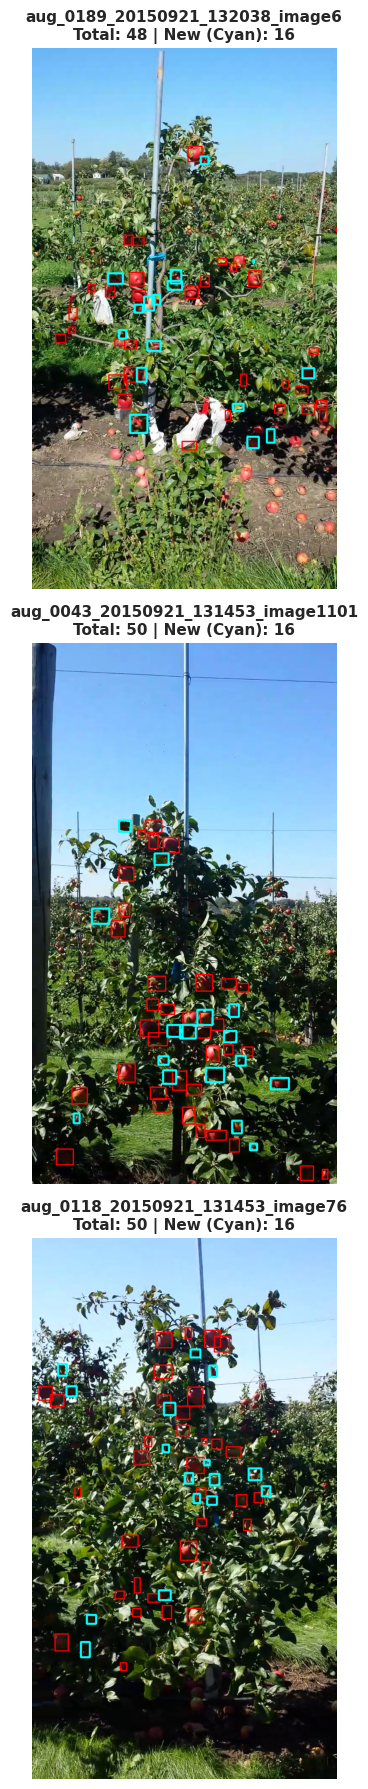

✓ Displayed 3 sample augmented images (new objects in cyan)


In [4]:
# Find and display sample augmented images
print("\n" + "="*70)
print("SAMPLE AUGMENTED IMAGES WITH NEW OBJECTS")
print("="*70)

augmented_images_dir = AUGMENTED_DATASET_TRAIN / "images"
augmented_labels_dir = AUGMENTED_DATASET_TRAIN / "labels"
original_labels_dir = ORIGINAL_DATASET_TRAIN / "labels"

# Build mapping of original image to object count
original_object_counts = {}
for label_file in original_labels_dir.glob("*.txt"):
    boxes = load_yolo_labels(label_file)
    original_object_counts[label_file.stem] = len(boxes)

# Find augmented images and count new objects
augmented_images_info = []
for label_file in augmented_labels_dir.glob("aug_*.txt"):
    label_stem = label_file.stem
    aug_boxes = load_yolo_labels(label_file)
    
    # Find corresponding image
    img_candidates = list(augmented_images_dir.glob(f"{label_stem}.*"))
    if not img_candidates:
        continue
    
    img_path = img_candidates[0]
    
    # Extract original image name from aug_XXXX_ORIGINALNAME format
    parts = label_stem.split('_', 2)
    if len(parts) >= 3:
        original_stem = '_'.join(parts[2:])
        original_count = original_object_counts.get(original_stem, 0)
        new_count = len(aug_boxes) - original_count
        
        augmented_images_info.append({
            'stem': label_stem,
            'img_path': img_path,
            'total_objects': len(aug_boxes),
            'original_objects': original_count,
            'new_objects': new_count
        })

# Sort by number of new objects
augmented_images_info.sort(key=lambda x: x['new_objects'], reverse=True)

print(f"Found {len(augmented_images_info)} augmented images")
print(f"Total new objects: {sum(x['new_objects'] for x in augmented_images_info)}")

# Display top 3 augmented images
sample_size = min(3, len(augmented_images_info))
if sample_size > 0:
    fig, axes = plt.subplots(sample_size, 1, figsize=(16, 6*sample_size))
    if sample_size == 1:
        axes = [axes]

    for idx, aug_info in enumerate(augmented_images_info[:sample_size]):
        img_path = aug_info['img_path']
        label_path = augmented_labels_dir / f"{aug_info['stem']}.txt"
        
        boxes = load_yolo_labels(label_path)
        highlight_indices = set(range(aug_info['original_objects'], len(boxes)))
        
        img_with_boxes = draw_bboxes_on_image(img_path, boxes, highlight_indices=highlight_indices)
        
        if img_with_boxes is not None:
            axes[idx].imshow(img_with_boxes)
            title = f"{aug_info['stem']}\nTotal: {aug_info['total_objects']} | New (Cyan): {aug_info['new_objects']}"
            axes[idx].set_title(title, fontsize=11, fontweight='bold')
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"✓ Displayed {sample_size} sample augmented images (new objects in cyan)")
else:
    print("No augmented images found")


In [5]:
# Analyze objects
print("\n" + "="*70)
print("OBJECT ANALYSIS")
print("="*70)

df_original = analyze_objects_in_split(
    ORIGINAL_DATASET_TRAIN / "labels",
    ORIGINAL_DATASET_TRAIN / "images",
    "original"
)

df_augmented = analyze_objects_in_split(
    AUGMENTED_DATASET_TRAIN / "labels",
    AUGMENTED_DATASET_TRAIN / "images",
    "augmented"
)

# Identify augmented images
augmented_image_names = {f.stem for f in augmented_counts['files'] if f.stem.startswith("aug_")}
df_new_objects = df_augmented[df_augmented['image_name'].isin(augmented_image_names)]

print(f"\nOriginal dataset objects: {len(df_original)}")
print(f"Augmented dataset objects: {len(df_augmented)}")
print(f"NEW objects (in augmented images): {len(df_new_objects)}")
print(f"Total increase: {len(df_augmented) - len(df_original)} objects ({(len(df_augmented) - len(df_original)) / len(df_original) * 100:.1f}%)")

# Count augmented images
augmented_only = [f for f in augmented_counts['files'] if f.stem.startswith("aug_")]
print(f"\nAugmented images added: {len(augmented_only)}")
if len(augmented_only) > 0:
    print(f"Objects per augmented image: {len(df_new_objects) / len(augmented_only):.1f}")



OBJECT ANALYSIS



Original dataset objects: 22815
Augmented dataset objects: 34849
NEW objects (in augmented images): 12034
Total increase: 12034 objects (52.7%)

Augmented images added: 268
Objects per augmented image: 44.9


In [6]:
# Size distribution analysis
print("\n" + "="*70)
print("OBJECT SIZE DISTRIBUTION (COCO-based)")
print("="*70)

def get_size_distribution(dataframe):
    """Get size distribution counts and percentages"""
    size_dist = dataframe['size_category'].value_counts().sort_index()
    size_pct = (dataframe['size_category'].value_counts(normalize=True) * 100).sort_index()
    return size_dist, size_pct

orig_dist, orig_pct = get_size_distribution(df_original)
aug_dist, aug_pct = get_size_distribution(df_augmented)
new_dist, new_pct = get_size_distribution(df_new_objects)

print(f"\n{'Original Dataset Size Distribution:':^70}")
for size_cat in ['small', 'medium', 'large']:
    count = orig_dist.get(size_cat, 0)
    pct = orig_pct.get(size_cat, 0)
    print(f"  {size_cat:8s}: {count:6d} objects ({pct:6.2f}%)")

print(f"\n{'Augmented Dataset Size Distribution:':^70}")
for size_cat in ['small', 'medium', 'large']:
    count = aug_dist.get(size_cat, 0)
    pct = aug_pct.get(size_cat, 0)
    print(f"  {size_cat:8s}: {count:6d} objects ({pct:6.2f}%)")

print(f"\n{'NEW OBJECTS ONLY (in augmented images):':^70}")
for size_cat in ['small', 'medium', 'large']:
    count = new_dist.get(size_cat, 0)
    pct = new_pct.get(size_cat, 0)
    print(f"  {size_cat:8s}: {count:6d} objects ({pct:6.2f}%)")



OBJECT SIZE DISTRIBUTION (COCO-based)

                 Original Dataset Size Distribution:                  
  small   :  16793 objects ( 73.61%)
  medium  :   6022 objects ( 26.39%)
  large   :      0 objects (  0.00%)

                 Augmented Dataset Size Distribution:                 
  small   :  25911 objects ( 74.35%)
  medium  :   8938 objects ( 25.65%)
  large   :      0 objects (  0.00%)

               NEW OBJECTS ONLY (in augmented images):                
  small   :   9118 objects ( 75.77%)
  medium  :   2916 objects ( 24.23%)
  large   :      0 objects (  0.00%)



VISUALIZATIONS


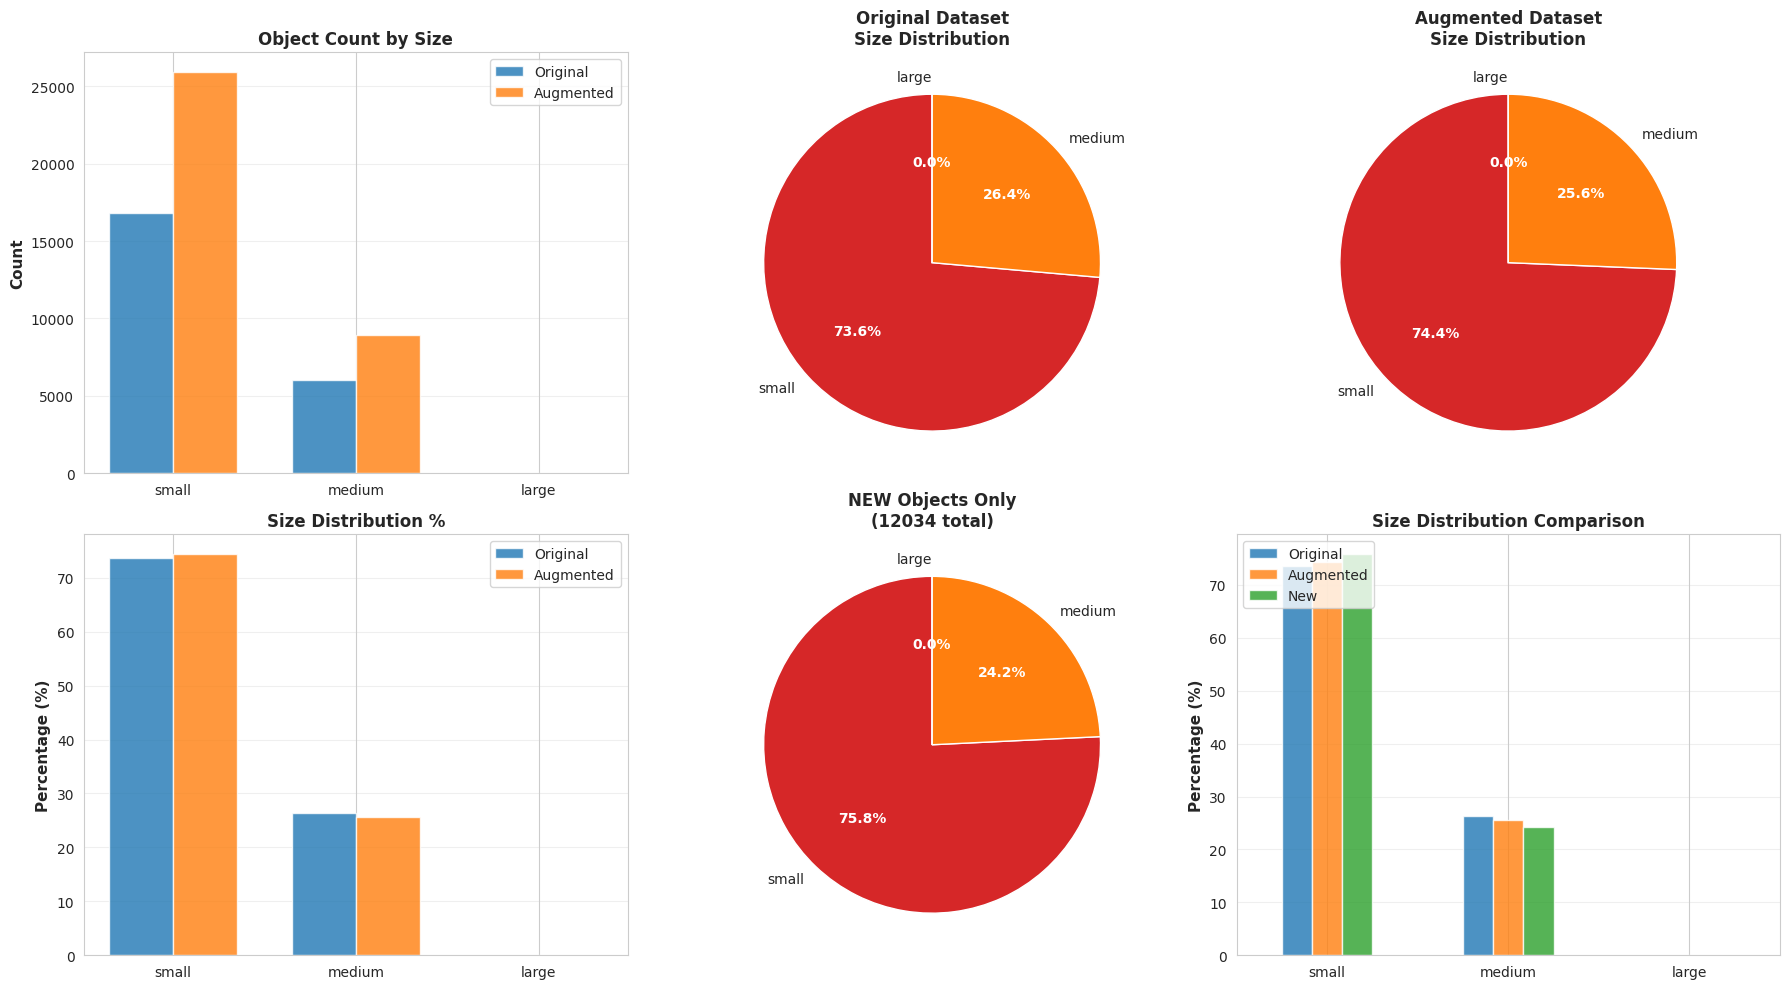

✓ Size distribution visualizations created


In [7]:
# Comprehensive size distribution visualizations
print("\n" + "="*70)
print("VISUALIZATIONS")
print("="*70)

categories = ['small', 'medium', 'large']
orig_counts_list = [orig_dist.get(c, 0) for c in categories]
aug_counts_list = [aug_dist.get(c, 0) for c in categories]
original_pcts = [orig_pct.get(c, 0) for c in categories]
augmented_pcts = [aug_pct.get(c, 0) for c in categories]
new_pcts = [new_pct.get(c, 0) for c in categories]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Absolute count comparison
ax = axes[0, 0]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, orig_counts_list, width, label='Original', alpha=0.8, color='#1f77b4')
ax.bar(x + width/2, aug_counts_list, width, label='Augmented', alpha=0.8, color='#ff7f0e')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Object Count by Size', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Original dataset pie chart
ax = axes[0, 1]
colors = ['#d62728', '#ff7f0e', '#2ca02c']
wedges, texts, autotexts = ax.pie(orig_counts_list, labels=categories, autopct='%1.1f%%',
                                    colors=colors, startangle=90)
ax.set_title('Original Dataset\nSize Distribution', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Augmented dataset pie chart
ax = axes[0, 2]
wedges, texts, autotexts = ax.pie(aug_counts_list, labels=categories, autopct='%1.1f%%',
                                    colors=colors, startangle=90)
ax.set_title('Augmented Dataset\nSize Distribution', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 4. Percentage comparison
ax = axes[1, 0]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, original_pcts, width, label='Original', alpha=0.8, color='#1f77b4')
ax.bar(x + width/2, augmented_pcts, width, label='Augmented', alpha=0.8, color='#ff7f0e')
ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Size Distribution %', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. New objects only pie chart
ax = axes[1, 1]
new_counts = [new_dist.get(c, 0) for c in categories]
wedges, texts, autotexts = ax.pie(new_counts, labels=categories, autopct='%1.1f%%',
                                    colors=colors, startangle=90)
ax.set_title(f'NEW Objects Only\n({len(df_new_objects)} total)', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 6. Comparison across datasets
ax = axes[1, 2]
data_comparison = pd.DataFrame({
    'Original': original_pcts,
    'Augmented': augmented_pcts,
    'New': new_pcts
}, index=categories)
data_comparison.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Size Distribution Comparison', fontsize=12, fontweight='bold')
ax.set_xticklabels(categories, rotation=0)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Size distribution visualizations created")


In [8]:
# Summary report
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

# Calculate totals correctly
original_images_total = sum([orig_dist.get(c, 0) for c in ['small', 'medium', 'large']])
augmented_images_total = sum([aug_dist.get(c, 0) for c in ['small', 'medium', 'large']])

summary_data = {
    'Metric': [
        'Total Images',
        'Total Objects',
        'Small Objects',
        'Medium Objects',
        'Large Objects',
        'Objects/Image'
    ],
    'Original': [
        len(original_counts['files']),
        len(df_original),
        orig_dist.get('small', 0),
        orig_dist.get('medium', 0),
        orig_dist.get('large', 0),
        f"{len(df_original) / len(original_counts['files']):.2f}" if len(original_counts['files']) > 0 else 0
    ],
    'Augmented': [
        len(augmented_counts['files']),
        len(df_augmented),
        aug_dist.get('small', 0),
        aug_dist.get('medium', 0),
        aug_dist.get('large', 0),
        f"{len(df_augmented) / len(augmented_counts['files']):.2f}" if len(augmented_counts['files']) > 0 else 0
    ],
    'Change': [
        len(augmented_only),
        len(df_new_objects),
        new_dist.get('small', 0),
        new_dist.get('medium', 0),
        new_dist.get('large', 0),
        f"{len(df_new_objects) / len(augmented_only):.2f}" if len(augmented_only) > 0 else 0
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"\n✓ Dataset expanded from {len(original_counts['files'])} to {len(augmented_counts['files'])} images")
print(f"  ({len(augmented_only)} new augmented images, {len(augmented_only)/len(original_counts['files'])*100:.1f}% expansion)")

print(f"\n✓ Objects increased from {len(df_original)} to {len(df_augmented)}")
print(f"  ({len(df_new_objects)} new objects, {len(df_new_objects)/len(df_original)*100:.1f}% increase)")

print(f"\n✓ Average objects per image: {len(df_original) / len(original_counts['files']):.2f} → {len(df_augmented) / len(augmented_counts['files']):.2f}")

print(f"\n✓ Size distribution of new objects:")
for size_cat in ['small', 'medium', 'large']:
    pct = new_pct.get(size_cat, 0)
    count = new_dist.get(size_cat, 0)
    print(f"  - {size_cat:8s}: {count:4d} objects ({pct:5.1f}%)")



SUMMARY REPORT

        Metric Original Augmented Change
  Total Images      536       804    268
 Total Objects    22815     34849  12034
 Small Objects    16793     25911   9118
Medium Objects     6022      8938   2916
 Large Objects        0         0      0
 Objects/Image    42.57     43.34  44.90

KEY INSIGHTS

✓ Dataset expanded from 536 to 804 images
  (268 new augmented images, 50.0% expansion)

✓ Objects increased from 22815 to 34849
  (12034 new objects, 52.7% increase)

✓ Average objects per image: 42.57 → 43.34

✓ Size distribution of new objects:
  - small   : 9118 objects ( 75.8%)
  - medium  : 2916 objects ( 24.2%)
  - large   :    0 objects (  0.0%)



OBJECT AREA DISTRIBUTION


/tmp/ipykernel_974434/2047544004.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Original', 'Augmented', 'New'],


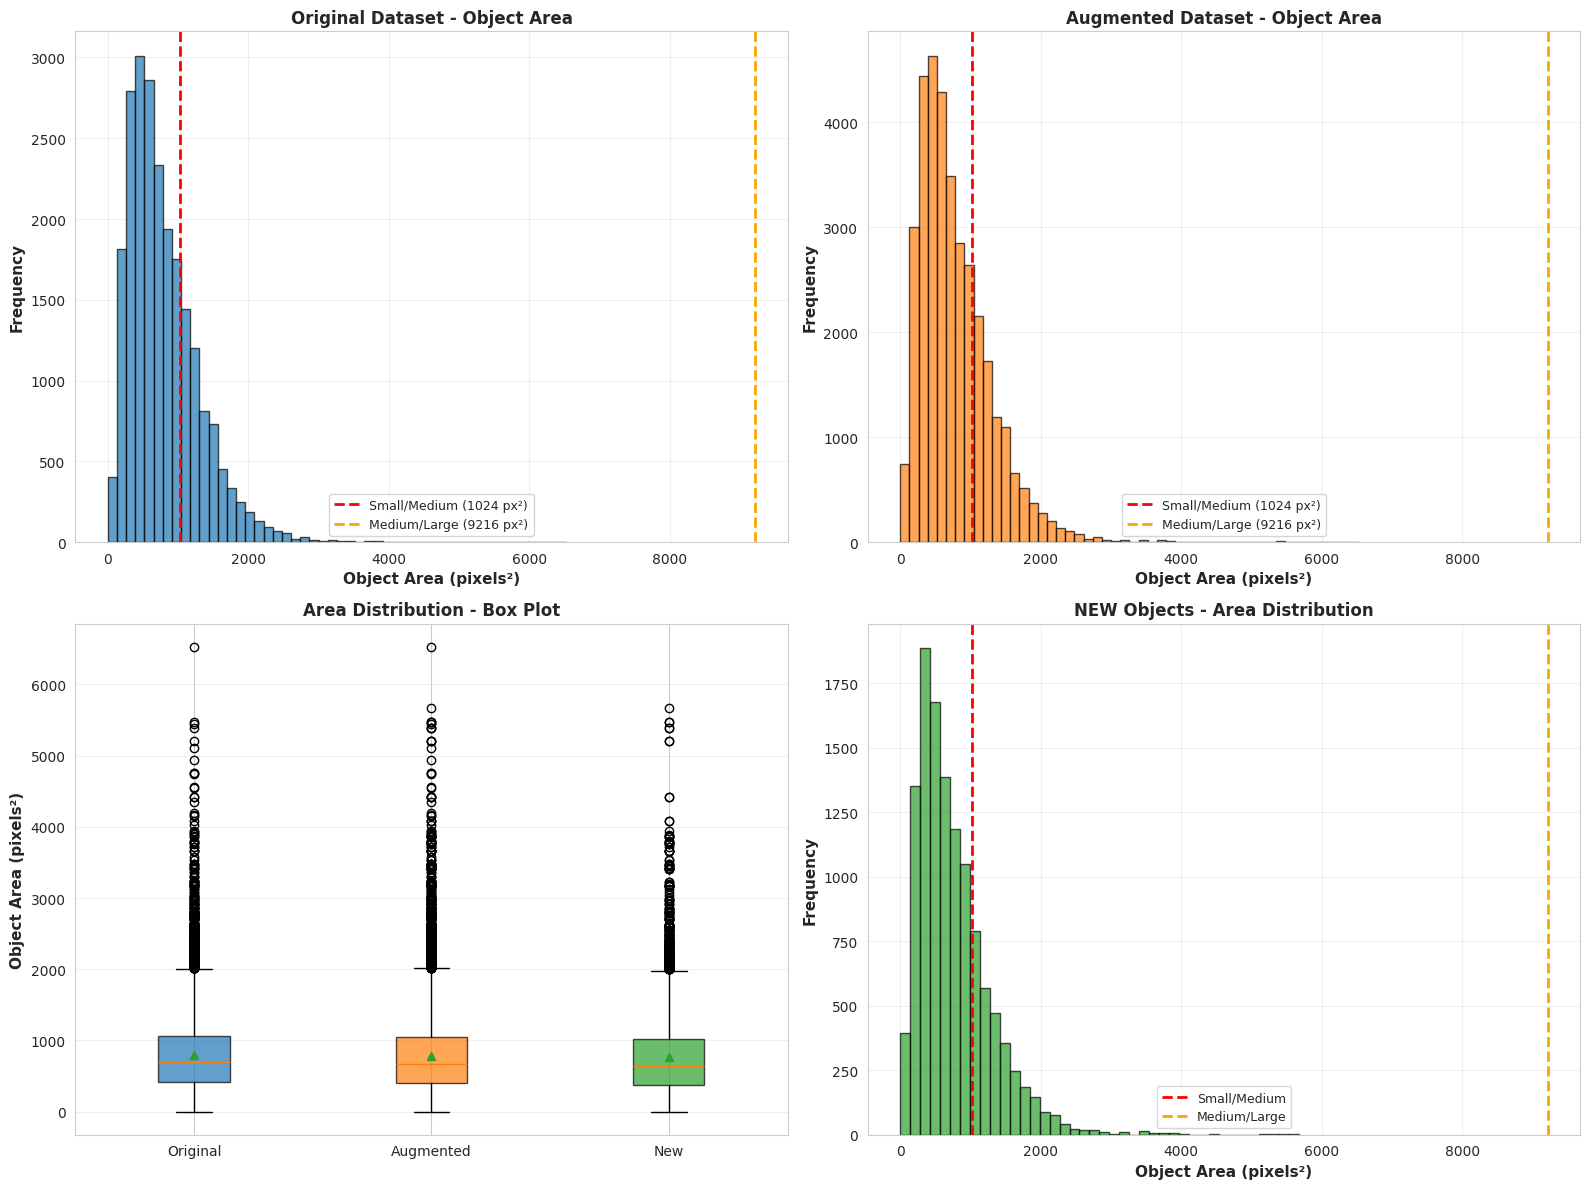


Detailed Object Area Statistics:
----------------------------------------------------------------------
Mean Area (px²)      | Original:    796.5 | Augmented:    784.3 | New:    761.2
Median Area (px²)    | Original:    690.0 | Augmented:    672.0 | New:    638.0
Std Dev (px²)        | Original:    512.3 | Augmented:    518.9 | New:    530.4
Min Area (px²)       | Original:      1.0 | Augmented:      1.0 | New:      1.0
Max Area (px²)       | Original:   6525.0 | Augmented:   6525.0 | New:   5670.0

✓ Area distribution visualizations created


In [9]:
# Object area distribution analysis
print("\n" + "="*70)
print("OBJECT AREA DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Original objects area histogram
ax = axes[0, 0]
ax.hist(df_original['area_pixels'], bins=50, color='#1f77b4', alpha=0.7, edgecolor='black')
ax.axvline(1024, color='red', linestyle='--', linewidth=2, label='Small/Medium (1024 px²)')
ax.axvline(9216, color='orange', linestyle='--', linewidth=2, label='Medium/Large (9216 px²)')
ax.set_xlabel('Object Area (pixels²)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Original Dataset - Object Area', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Augmented objects area histogram
ax = axes[0, 1]
ax.hist(df_augmented['area_pixels'], bins=50, color='#ff7f0e', alpha=0.7, edgecolor='black')
ax.axvline(1024, color='red', linestyle='--', linewidth=2, label='Small/Medium (1024 px²)')
ax.axvline(9216, color='orange', linestyle='--', linewidth=2, label='Medium/Large (9216 px²)')
ax.set_xlabel('Object Area (pixels²)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Augmented Dataset - Object Area', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Box plot comparison
ax = axes[1, 0]
data_to_plot = [
    df_original['area_pixels'],
    df_augmented['area_pixels'],
    df_new_objects['area_pixels']
]
bp = ax.boxplot(data_to_plot, labels=['Original', 'Augmented', 'New'],
                patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Object Area (pixels²)', fontsize=11, fontweight='bold')
ax.set_title('Area Distribution - Box Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. New objects area histogram
ax = axes[1, 1]
ax.hist(df_new_objects['area_pixels'], bins=40, color='#2ca02c', alpha=0.7, edgecolor='black')
ax.axvline(1024, color='red', linestyle='--', linewidth=2, label='Small/Medium')
ax.axvline(9216, color='orange', linestyle='--', linewidth=2, label='Medium/Large')
ax.set_xlabel('Object Area (pixels²)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('NEW Objects - Area Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics table
print("\nDetailed Object Area Statistics:")
print("-" * 70)
for metric_name, metric_func in [
    ('Mean Area (px²)', lambda x: f"{x.mean():.1f}"),
    ('Median Area (px²)', lambda x: f"{x.median():.1f}"),
    ('Std Dev (px²)', lambda x: f"{x.std():.1f}"),
    ('Min Area (px²)', lambda x: f"{x.min():.1f}"),
    ('Max Area (px²)', lambda x: f"{x.max():.1f}")
]:
    orig_val = metric_func(df_original['area_pixels'])
    aug_val = metric_func(df_augmented['area_pixels'])
    new_val = metric_func(df_new_objects['area_pixels'])
    print(f"{metric_name:20s} | Original: {orig_val:>8s} | Augmented: {aug_val:>8s} | New: {new_val:>8s}")

print("\n✓ Area distribution visualizations created")


In [10]:
# Export analysis results
print("\n" + "="*70)
print("EXPORT ANALYSIS RESULTS")
print("="*70)

export_dir = AUGMENTED_DATASET_TRAIN.parent / "analysis_results"
export_dir.mkdir(parents=True, exist_ok=True)

# Export dataframes
df_original.to_csv(export_dir / "01_original_objects.csv", index=False)
print(f"✓ Exported: 01_original_objects.csv")

df_augmented.to_csv(export_dir / "02_augmented_objects.csv", index=False)
print(f"✓ Exported: 02_augmented_objects.csv")

df_new_objects.to_csv(export_dir / "03_new_objects_only.csv", index=False)
print(f"✓ Exported: 03_new_objects_only.csv")

# Export summary
summary_df.to_csv(export_dir / "04_summary.csv", index=False)
print(f"✓ Exported: 04_summary.csv")

# Create comparison report
comparison_report = {
    'Category': [
        'Total Images',
        'Total Objects',
        'Small Objects',
        'Medium Objects', 
        'Large Objects',
        'Small %',
        'Medium %',
        'Large %'
    ],
    'Original': [
        len(original_counts['files']),
        len(df_original),
        orig_dist.get('small', 0),
        orig_dist.get('medium', 0),
        orig_dist.get('large', 0),
        f"{orig_pct.get('small', 0):.2f}%",
        f"{orig_pct.get('medium', 0):.2f}%",
        f"{orig_pct.get('large', 0):.2f}%"
    ],
    'Augmented': [
        len(augmented_counts['files']),
        len(df_augmented),
        aug_dist.get('small', 0),
        aug_dist.get('medium', 0),
        aug_dist.get('large', 0),
        f"{aug_pct.get('small', 0):.2f}%",
        f"{aug_pct.get('medium', 0):.2f}%",
        f"{aug_pct.get('large', 0):.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_report)
comparison_df.to_csv(export_dir / "05_comparison_report.csv", index=False)
print(f"✓ Exported: 05_comparison_report.csv")

print(f"\n✓ All results exported to: {export_dir}")
print("\nAnalysis Complete! 🎉")



EXPORT ANALYSIS RESULTS
✓ Exported: 01_original_objects.csv
✓ Exported: 02_augmented_objects.csv
✓ Exported: 03_new_objects_only.csv
✓ Exported: 04_summary.csv
✓ Exported: 05_comparison_report.csv

✓ All results exported to: /home/khanh/Projects/DifficultyAgri/results/05_copy_paste_exp/Step_4_Copy_Paste_Augmentation/augmented_dataset/analysis_results

Analysis Complete! 🎉
